# Contextual and Non‑Contextual Decomposition of Molecular Hamiltonian

This notebook demonstrates how to generate a molecular Hamiltonian using **OpenFermion**, and how to separate that Hamiltonian into contextual and non‑contextual parts using the *contextual subspace* techniques from the `cs_vqe` module (as described in the `CS_VQE_how_to_use.ipynb` notebook).

Given a molecular geometry, we

1. Generate the fermionic and qubit Hamiltonians via `openfermionpyscf` and the Jordan‑Wigner transform.
2. Convert the qubit Hamiltonian into a simple dictionary format expected by the `cs_vqe` routines.
3. Use `cs_vqe.greedy_dfs` to approximate a large non‑contextual sub‑Hamiltonian and then extract the corresponding contextual part.
4. Convert the contextual part back into the standard OpenFermion formats (`FermionOperator` and `QubitOperator`).

This workflow follows the approach outlined in the `ContextualSubspaceVQE` repository – particularly the functions `contextualQ_ham` and `greedy_dfs` described by Kirby \_et al.\_


## Prerequisites
Before running this notebook you need to install the following packages in your Python environment:

- `openfermion`: The quantum simulation library for chemistry.
- `openfermionpyscf`: Provides a wrapper for PySCF to compute molecular integrals.
- `cs_vqe`: The Contextual Subspace VQE package (see the repository [wmkirby1/ContextualSubspaceVQE](https://github.com/wmkirby1/ContextualSubspaceVQE)).

If any of these packages are not installed, install them using `pip install openfermion openfermionpyscf contextual-subspace-vqe` or by cloning the respective GitHub repositories and adding them to your `PYTHONPATH` as shown in the official tutorial.

In [2]:
from openfermion import MolecularData
from openfermionpyscf import run_pyscf
from openfermion.transforms import jordan_wigner

In [ ]:
# Define multiple molecular geometries.
# Each geometry is a list of tuples: (atom symbol, (x, y, z) in atomic units)

geometries = [
    # Geometry 1: Larger molecule (absolute energy: -492.786889)
    #[
    #    ('C', (-0.288346, 0.723178, 0.872948)),
    #    ('C', (-0.288249, -0.722959, 0.873144)),
    #    ('H', (-1.280153, 1.002851, 0.142283)),
    #    ('H', (-0.492354, 1.301868, 1.770883)),
    #    ('H', (-1.279406, -1.003258, 0.142460)),
    #    ('H', (-0.492048, -1.301456, 1.771243)),
    #    ('O', (0.874871, 1.114520, 0.203874)),
    #    ('O', (0.875179, -1.114451, 0.204365)),
    #    ('C', (1.552997, -0.000009, -0.222967)),
    #    ('O', (2.554737, 0.000033, -0.848568)),
    #    ('O', (-2.296902, -0.655858, -0.590465)),
    #    ('O', (-2.297190, 0.655597, -0.589909)),
    #],
    # Geometry 2: Ethylene carbonate (EC) (absolute energy: -342.503368)
        [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (2.000000, 0.000000, 0.602743)),
        ('O', (2.000000, 0.000000, -0.602743)),
    ],
        [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (3.000000, 0.000000, 0.602743)),
        ('O', (3.000000, 0.000000, -0.602743)),
    ],
        [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (10.000000, 0.000000, 0.602743)),
        ('O', (10.000000, 0.000000, -0.602743)),
    ],
        [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (20.000000, 0.000000, 0.602743)),
        ('O', (20.000000, 0.000000, -0.602743)),
    ],
        [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (30.000000, 0.000000, 0.602743)),
        ('O', (30.000000, 0.000000, -0.602743)),
    ],
    [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (40.000000, 0.000000, 0.602743)),
        ('O', (40.000000, 0.000000, -0.602743)),
    ],
]



basis = 'sto-3g'
multiplicity = 1
charge = 0

# CAS(10,12): 10 active electrons in 12 active orbitals
n_active_electrons = 6
n_active_orbitals = 8

# Process all geometries
molecules = []
fermion_hams = []
qubit_hams = []

for i, geometry in enumerate(geometries):
    print(f"\n{'='*60}")
    print(f"Processing Geometry {i+1}")
    print(f"{'='*60}")
    
    # Create a MolecularData object and run PySCF to compute the integrals.
    molecule = MolecularData(geometry, basis, multiplicity, charge)
    molecule = run_pyscf(molecule, run_scf=True, run_mp2=False, run_cisd=False, run_ccsd=False, run_fci=False)
    
    # Use an active-space Hamiltonian: CAS(10,12).
    # Freeze the core orbitals and keep 12 active orbitals.
    n_core_orbitals = (molecule.n_electrons - n_active_electrons) // 2
    occupied_indices = list(range(n_core_orbitals))
    active_indices = list(range(n_core_orbitals, n_core_orbitals + n_active_orbitals))
    
    # Obtain the fermionic Hamiltonian in the active space and map it to a qubit Hamiltonian.
    fermion_ham = molecule.get_molecular_hamiltonian(
        occupied_indices=occupied_indices,
        active_indices=active_indices,
    )
    qubit_ham = jordan_wigner(fermion_ham)
    
    molecules.append(molecule)
    fermion_hams.append(fermion_ham)
    qubit_hams.append(qubit_ham)
    
    # Display the qubit Hamiltonian.
    print(f'Qubit Hamiltonian for Geometry {i+1}:')
    print(qubit_ham)



Processing Geometry 1
Qubit Hamiltonian for Geometry 1:
-478.6167373355992 [] +
-0.0041561661301464286 [X0 X1 Y2 Y3] +
-7.502453858853236e-07 [X0 X1 Y2 Z3 Z4 Y5] +
0.0008654036676324281 [X0 X1 Y2 Z3 Z4 Z5 Z6 Y7] +
-3.243035260431211e-06 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Y9] +
6.203920731005788e-05 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
-0.0010263663788351372 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Y13] +
-1.1114838060950976e-06 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13 Z14 Y15] +
-7.502453858853236e-07 [X0 X1 X3 X4] +
0.0008654036676324281 [X0 X1 X3 Z4 Z5 X6] +
-3.2430352604312115e-06 [X0 X1 X3 Z4 Z5 Z6 Z7 X8] +
6.203920731005788e-05 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 X10] +
-0.0010263663788351372 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 X12] +
-1.1114838060950976e-06 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13 X14] +
-0.004535149855955177 [X0 X1 Y4 Y5] +
-2.9458112932310655e-06 [X0 X1 Y4 Z5 Z6 Y7] +
-0.0007127761666529439 [X0 X1 Y4 Z5 Z6 Z7 Z8 Y9] +
-7.975924890679822e-08 [X0 X1 Y4 Z5 Z6 Z7

In [21]:
# Helper: convert an OpenFermion QubitOperator to a dictionary of Pauli strings.
def qubit_operator_to_dict(qubit_op):
    """Return a dict mapping Pauli strings to coefficients.
    The Pauli string is a string over 
        {'I', 'X', 'Y', 'Z'} of length equal to the number of qubits.
    Example: QubitOperator("X0 Y2", 0.5) on 3 qubits becomes {'XIY': 0.5}.
    """
    # Determine number of qubits by inspecting the largest qubit index in the operator.
    n_qubits = 0
    for term in qubit_op.terms:
        for qubit_index, pauli in term:
            if qubit_index + 1 > n_qubits:
                n_qubits = qubit_index + 1

    ham_dict = {}
    for term, coeff in qubit_op.terms.items():
        pauli_list = ['I'] * n_qubits
        for qubit_index, pauli in term:
            pauli_list[qubit_index] = pauli
        pauli_str = ''.join(pauli_list)
        # Combine coefficients if the same Pauli string appears multiple times.
        ham_dict[pauli_str] = ham_dict.get(pauli_str, 0.0) + coeff
    return ham_dict

# Convert all qubit Hamiltonians to the dictionary format used by cs_vqe.
ham_dicts = []
for i, qubit_ham in enumerate(qubit_hams):
    ham_dict = qubit_operator_to_dict(qubit_ham)
    ham_dicts.append(ham_dict)
    
    # Inspect the dictionary representation.
    print(f'\nHamiltonian {i+1} as dictionary (Pauli string -> coefficient):')
    for pauli_str, coeff in ham_dict.items():
        print(f'{coeff:+.6f} 	 {pauli_str}')



Hamiltonian 1 as dictionary (Pauli string -> coefficient):
-478.616737 	 IIIIIIIIIIIIIIII
-0.223792 	 ZIIIIIIIIIIIIIII
-0.223792 	 IZIIIIIIIIIIIIII
-0.219658 	 IIZIIIIIIIIIIIII
-0.219658 	 IIIZIIIIIIIIIIII
-0.318143 	 IIIIZIIIIIIIIIII
-0.318143 	 IIIIIZIIIIIIIIII
-0.446729 	 IIIIIIZIIIIIIIII
-0.446729 	 IIIIIIIZIIIIIIII
-0.471890 	 IIIIIIIIZIIIIIII
-0.471890 	 IIIIIIIIIZIIIIII
-0.384869 	 IIIIIIIIIIZIIIII
-0.384869 	 IIIIIIIIIIIZIIII
-0.590667 	 IIIIIIIIIIIIZIII
-0.590667 	 IIIIIIIIIIIIIZII
-0.628582 	 IIIIIIIIIIIIIIZI
-0.628582 	 IIIIIIIIIIIIIIIZ
+0.096021 	 ZZIIIIIIIIIIIIII
-0.003012 	 XZXIIIIIIIIIIIII
-0.003012 	 YZYIIIIIIIIIIIII
+0.057550 	 ZIZIIIIIIIIIIIII
+0.061706 	 ZIIZIIIIIIIIIIII
+0.000004 	 XZZZXIIIIIIIIIII
+0.000004 	 YZZZYIIIIIIIIIII
+0.054328 	 ZIIIZIIIIIIIIIII
+0.058863 	 ZIIIIZIIIIIIIIII
-0.010968 	 XZZZZZXIIIIIIIII
-0.010968 	 YZZZZZYIIIIIIIII
+0.089205 	 ZIIIIIZIIIIIIIII
+0.093021 	 ZIIIIIIZIIIIIIII
+0.000019 	 XZZZZZZZXIIIIIII
+0.000019 	 YZZZZZZZYIIIIIII
+0.066140 

In [ ]:
# Apply contextual subspace routines to split the Hamiltonian.
# We approximate a large non‑contextual sub‑Hamiltonian using greedy depth‑first search.

import cs_vqe as c

# Process all geometries
noncon_dicts = []
contextual_dicts = []

for i, ham_dict in enumerate(ham_dicts):
    print(f"\n{'='*60}")
    print(f"Processing Hamiltonian {i+1} with greedy_dfs")
    print(f"{'='*60}")
    
    # The greedy_dfs function takes the Hamiltonian dictionary, a timeout (in seconds),
    # and an optional criterion ('weight' or 'size').
    # It returns a list of candidate noncontextual subsets of Pauli terms; the last element
    # in this list is the best candidate found within the time limit.
    noncon_candidates = c.greedy_dfs(ham_dict, cutoff=1, criterion='weight')
    
    # Choose the final candidate (largest total weight) as the noncontextual subset.
    noncon_terms = set(noncon_candidates[-1])
    print(f"Number of terms in noncontextual subset: {len(noncon_terms)}")
    
    # Construct the noncontextual and contextual Hamiltonians in dictionary form.
    noncon_dict = {pauli: ham_dict[pauli] for pauli in noncon_terms}
    contextual_dict = {pauli: ham_dict[pauli] for pauli in ham_dict.keys() if pauli not in noncon_terms}
    
    noncon_dicts.append(noncon_dict)
    contextual_dicts.append(contextual_dict)
    
    print('Non‑contextual Hamiltonian:')
    for pauli, coeff in noncon_dict.items():
        print(f'{coeff:+.6f} 	 {pauli}')
    
    print('Contextual Hamiltonian:')
    for pauli, coeff in contextual_dict.items():
        print(f'{coeff:+.6f} 	 {pauli}')



Processing Hamiltonian 1 with greedy_dfs
Number of terms in noncontextual subset: 141
Non‑contextual Hamiltonian:
+0.058863 	 IZIIZIIIIIIIIIII
+0.068271 	 IIIZIZIIIIIIIIII
+0.079880 	 ZIIIIIIIIIIIIIIZ
-0.446729 	 IIIIIIIZIIIIIIII
+0.079521 	 IIIIIIIIIIZIZIII
+0.057550 	 ZIZIIIIIIIIIIIII
+0.062640 	 IIZIIIIIIIIIIIZI
+0.058863 	 ZIIIIZIIIIIIIIII
+0.099709 	 IIIIIIZIIIIIIIIZ
+0.048365 	 IIIIIZIZIIIIIIII
+0.099709 	 IIIIIIIZIIIIIIZI
+0.066140 	 ZIIIIIIIZIIIIIII
+0.058796 	 IZIIIIIIIIZIIIII
+0.049171 	 IIIIIZZIIIIIIIII
+0.063182 	 IIIIIIIZIZIIIIII
+0.090515 	 IIZIIIIIIIIZIIII
-0.219658 	 IIIZIIIIIIIIIIII
+0.063684 	 IIIIIIIZZIIIIIII
+0.042412 	 IIIIIIIZIIIZIIII
+0.077484 	 IIIIZIIIIIIIZIII
+0.049521 	 IIIZIIIZIIIIIIII
-0.318143 	 IIIIZIIIIIIIIIII
+0.084140 	 IIIIIIIIZIIIIIIZ
+0.081909 	 IIIIIIIIIIIZZIII
+0.096021 	 ZZIIIIIIIIIIIIII
+0.063182 	 IIIIIIZIZIIIIIII
+0.062640 	 IIIZIIIIIIIIIIIZ
+0.074236 	 ZIIIIIIIIIIIIZII
+0.093021 	 ZIIIIIIZIIIIIIII
+0.095119 	 IIIIIIIIIZZIIIII
+0.080539 	 III

In [23]:
# Convert the contextual part back into QubitOperator and FermionOperator forms.
from openfermion import QubitOperator
from openfermion.transforms.opconversions import reverse_jordan_wigner

contextual_qubit_ops = []
contextual_fermion_ops = []

for i, contextual_dict in enumerate(contextual_dicts):
    print(f"\n{'='*60}")
    print(f"Converting contextual part for Geometry {i+1}")
    print(f"{'='*60}")
    
    # Build a QubitOperator from the contextual dictionary.
    contextual_qubit_op = QubitOperator()
    for pauli_str, coeff in contextual_dict.items():
        # Create a list of (qubit_index, pauli) tuples for non‑identity entries.
        term_list = []
        for index, pauli in enumerate(pauli_str):
            if pauli != 'I':
                term_list.append((index, pauli))
        # Use the QubitOperator constructor to add this term.
        contextual_qubit_op += QubitOperator(tuple(term_list), coeff)
    
    # Use the reverse Jordan‑Wigner transform to obtain a FermionOperator.
    contextual_fermion_op = reverse_jordan_wigner(contextual_qubit_op)
    
    contextual_qubit_ops.append(contextual_qubit_op)
    contextual_fermion_ops.append(contextual_fermion_op)
    
    print('Reduced contextual Hamiltonian (QubitOperator):')
    print(contextual_qubit_op)
    
    print('Reduced contextual Hamiltonian (FermionOperator):')
    print(contextual_fermion_op)



Converting contextual part for Geometry 1
Reduced contextual Hamiltonian (QubitOperator):
-0.0041561661301464286 [X0 X1 Y2 Y3] +
-7.502453858853236e-07 [X0 X1 Y2 Z3 Z4 Y5] +
0.0008654036676324281 [X0 X1 Y2 Z3 Z4 Z5 Z6 Y7] +
-3.243035260431211e-06 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Y9] +
6.203920731005788e-05 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
-0.0010263663788351372 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Y13] +
-1.1114838060950976e-06 [X0 X1 Y2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13 Z14 Y15] +
-7.502453858853236e-07 [X0 X1 X3 X4] +
0.0008654036676324281 [X0 X1 X3 Z4 Z5 X6] +
-3.2430352604312115e-06 [X0 X1 X3 Z4 Z5 Z6 Z7 X8] +
6.203920731005788e-05 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 X10] +
-0.0010263663788351372 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 X12] +
-1.1114838060950976e-06 [X0 X1 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Z12 Z13 X14] +
-0.004535149855955177 [X0 X1 Y4 Y5] +
-2.9458112932310655e-06 [X0 X1 Y4 Z5 Z6 Y7] +
-0.0007127761666529439 [X0 X1 Y4 Z5 Z6 Z7 Z8 Y9] +
-7.975924890679822e-08 [X0 X1 Y

In [24]:
# Build QubitOperators from the non-contextual dictionaries.
noncontextual_qubit_ops = []
noncontextual_fermion_ops = []

for i, noncon_dict in enumerate(noncon_dicts):
    print(f"\n{'='*60}")
    print(f"Converting non-contextual part for Geometry {i+1}")
    print(f"{'='*60}")
    
    # Build a QubitOperator from the non-contextual dictionary.
    noncontextual_qubit_op = QubitOperator()
    for pauli_str, coeff in noncon_dict.items():
        # Create a list of (qubit_index, pauli) tuples for non‑identity entries.
        term_list = []
        for index, pauli in enumerate(pauli_str):
            if pauli != 'I':
                term_list.append((index, pauli))
        # Use the QubitOperator constructor to add this term.
        noncontextual_qubit_op += QubitOperator(tuple(term_list), coeff)
    
    # Use the reverse Jordan‑Wigner transform to obtain a FermionOperator.
    noncontextual_fermion_op = reverse_jordan_wigner(noncontextual_qubit_op)
    
    noncontextual_qubit_ops.append(noncontextual_qubit_op)
    noncontextual_fermion_ops.append(noncontextual_fermion_op)
    
    print('Reduced non-contextual Hamiltonian (QubitOperator):')
    print(noncontextual_qubit_op)
    
    print('Reduced non-contextual Hamiltonian (FermionOperator):')
    print(noncontextual_fermion_op)



Converting non-contextual part for Geometry 1
Reduced non-contextual Hamiltonian (QubitOperator):
-478.6167373355992 [] +
-0.22379161878174772 [Z0] +
0.09602127684479733 [Z0 Z1] +
0.0575496988577663 [Z0 Z2] +
0.06170586498791272 [Z0 Z3] +
0.05432765978502421 [Z0 Z4] +
0.05886280964097939 [Z0 Z5] +
0.08920454346839175 [Z0 Z6] +
0.09302062492772988 [Z0 Z7] +
0.0661401787648651 [Z0 Z8] +
0.06897497264083764 [Z0 Z9] +
0.05778928156065319 [Z0 Z10] +
0.058796020199485544 [Z0 Z11] +
0.06921483167668566 [Z0 Z12] +
0.07423559222436497 [Z0 Z13] +
0.07503196807019342 [Z0 Z14] +
0.07988039266137778 [Z0 Z15] +
-0.2237916187817477 [Z1] +
0.06170586498791272 [Z1 Z2] +
0.0575496988577663 [Z1 Z3] +
0.05886280964097939 [Z1 Z4] +
0.05432765978502421 [Z1 Z5] +
0.09302062492772988 [Z1 Z6] +
0.08920454346839175 [Z1 Z7] +
0.06897497264083764 [Z1 Z8] +
0.0661401787648651 [Z1 Z9] +
0.058796020199485544 [Z1 Z10] +
0.05778928156065319 [Z1 Z11] +
0.07423559222436497 [Z1 Z12] +
0.06921483167668566 [Z1 Z13] +
0.07


Computing eigenvalues for Geometry 1
Lowest eigenvalues for Geometry 1:
[-481.77408603 -481.69726957 -481.69726957 -481.67634501 -481.67634501
 -481.66772665 -481.66772665 -481.64981806 -481.64981806 -481.62725068
 -481.62725068 -481.5663859 ]

Computing eigenvalues for Geometry 2
Lowest eigenvalues for Geometry 2:
[-483.43072123 -483.34684231 -483.34524641 -483.33096016 -483.329035
 -483.29823692 -483.29801908 -483.19658777 -483.19281719 -483.19233772
 -483.17414693 -483.16876266]

Computing eigenvalues for Geometry 3
Lowest eigenvalues for Geometry 3:
[-483.7238186  -483.7238186  -483.69678145 -483.69678145 -483.64273601
 -483.64267828 -483.49402138 -483.49402138 -483.48921749 -483.48921749
 -483.48834155 -483.48834155]

Computing eigenvalues for Geometry 4
Lowest eigenvalues for Geometry 4:
[-483.72383332 -483.72383332 -483.69679618 -483.69679618 -483.64272375
 -483.64272003 -483.49403964 -483.49403964 -483.48923238 -483.48923238
 -483.48836497 -483.48836497]

Computing eigenvalues

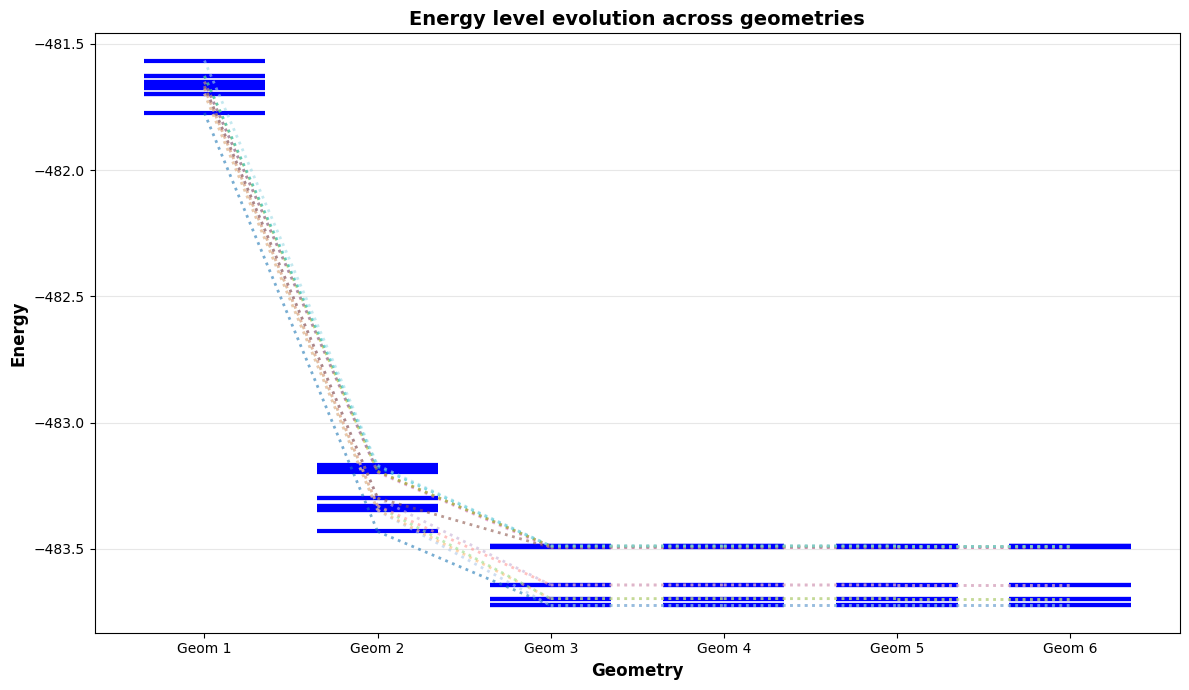

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from openfermion import get_sparse_operator, count_qubits
from scipy.sparse.linalg import eigsh


def get_lowest_eigenvalues_qubit(qubit_op, k=10, n_qubits=None, tol=1e-10):
    """
    Compute the lowest k eigenvalues of a QubitOperator efficiently.

    Parameters
    ----------
    qubit_op : openfermion.QubitOperator
        Hamiltonian in qubit form.
    k : int
        Number of lowest eigenvalues to compute.
    n_qubits : int or None
        Number of qubits. If None, inferred from qubit_op.
    tol : float
        Tolerance for sparse eigensolver.

    Returns
    -------
    evals : np.ndarray
        Sorted lowest eigenvalues.
    """
    if n_qubits is None:
        n_qubits = count_qubits(qubit_op)

    H_sparse = get_sparse_operator(qubit_op, n_qubits=n_qubits).tocsr()
    dim = H_sparse.shape[0]

    # If matrix is tiny, just diagonalize exactly.
    if dim <= 64 or k >= dim - 1:
        evals = np.linalg.eigvalsh(H_sparse.toarray())
        return np.sort(evals)[:k]

    # Sparse lowest-eigenvalue solve
    evals = eigsh(H_sparse, k=k, which="SA", return_eigenvectors=False, tol=tol)
    return np.sort(evals)


def plot_spectrum_all_geometries(evals_list, title="Low-energy spectrum across geometries", ylabel="Energy"):
    """
    Plot energy levels as horizontal spectral lines for each geometry.
    X-axis: geometry index
    Y-axis: energy values (showing discrete levels as horizontal lines)
    Dotted lines connect corresponding levels across geometries to show shifts.
    Each energy level has a unique color for the connecting dotted lines.
    """
    plt.figure(figsize=(12, 7))
    
    # Determine the maximum number of levels
    max_levels = max(len(evals) for evals in evals_list)
    
    # Define colors for each energy level
    colors = plt.cm.tab20(np.linspace(0, 1, max_levels))
    
    # Plot each geometry's spectrum
    for geom_idx, evals in enumerate(evals_list, start=1):
        for energy in evals:
            plt.hlines(energy, geom_idx - 0.35, geom_idx + 0.35, colors='blue', linewidth=3)
    
    # Draw dotted lines connecting corresponding levels between consecutive geometries
    for geom_idx in range(len(evals_list) - 1):
        evals_current = evals_list[geom_idx]
        evals_next = evals_list[geom_idx + 1]
        
        # Connect each level from current to next geometry
        for level_idx in range(min(len(evals_current), len(evals_next))):
            x_current = geom_idx + 1
            x_next = geom_idx + 2
            y_current = evals_current[level_idx]
            y_next = evals_next[level_idx]
            
            # Draw dotted lines with color corresponding to the energy level
            plt.plot([x_current, x_next], [y_current, y_next], ':', color=colors[level_idx], alpha=0.6, linewidth=2)
    
    plt.xlabel("Geometry", fontsize=12, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(range(1, len(evals_list) + 1), [f'Geom {i}' for i in range(1, len(evals_list) + 1)])
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Compute eigenvalues for all geometries
low_evals_list = []

for i, noncontextual_qubit_op in enumerate(noncontextual_qubit_ops):
    print(f"\n{'='*60}")
    print(f"Computing eigenvalues for Geometry {i+1}")
    print(f"{'='*60}")
    
    low_evals = get_lowest_eigenvalues_qubit(noncontextual_qubit_op, k=12)
    low_evals_list.append(low_evals)
    
    print(f"Lowest eigenvalues for Geometry {i+1}:")
    print(low_evals)

# Plot all geometries together
plot_spectrum_all_geometries(low_evals_list, title="Energy level evolution across geometries")


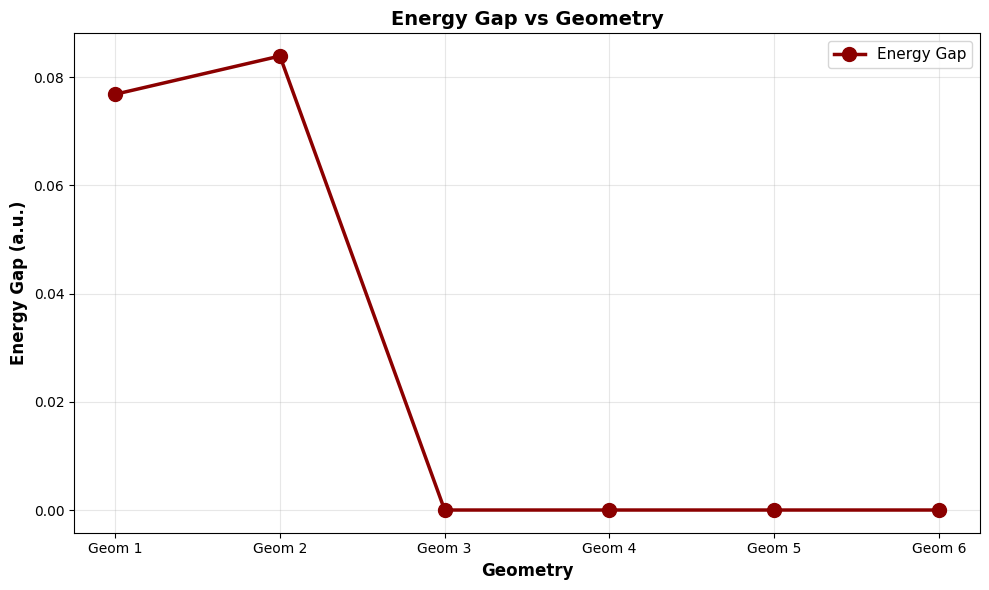


Energy gaps for each geometry:
Geometry 1: Gap = 0.076816 a.u.
Geometry 2: Gap = 0.083879 a.u.
Geometry 3: Gap = 0.000000 a.u.
Geometry 4: Gap = 0.000000 a.u.
Geometry 5: Gap = 0.000000 a.u.
Geometry 6: Gap = 0.000000 a.u.


In [26]:
# Plot the energy gap across geometries
def plot_energy_gap(evals_list, title="Energy gap evolution across geometries"):
    """
    Plot the energy gap (difference between first excited state and ground state)
    vs geometry index.
    """
    gaps = []
    
    for evals in evals_list:
        if len(evals) >= 2:
            gap = evals[1] - evals[0]  # First excited state - ground state
            gaps.append(gap)
        else:
            gaps.append(np.nan)
    
    plt.figure(figsize=(10, 6))
    
    geom_indices = range(1, len(gaps) + 1)
    plt.plot(geom_indices, gaps, 'o-', color='darkred', linewidth=2.5, markersize=10, label='Energy Gap')
    
    plt.xlabel("Geometry", fontsize=12, fontweight='bold')
    plt.ylabel("Energy Gap (a.u.)", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(geom_indices, [f'Geom {i}' for i in geom_indices])
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print("\nEnergy gaps for each geometry:")
    for i, gap in enumerate(gaps, start=1):
        print(f"Geometry {i}: Gap = {gap:.6f} a.u.")

# Plot the gap
plot_energy_gap(low_evals_list, title="Energy Gap vs Geometry")

In [ ]:
483.72383332-483.69679618

0.027037140000004456

## Data Flow Summary

- **Fermionic Hamiltonian**: Created from `MolecularData` using PySCF and stored as an `openfermion.FermionOperator`.
- **Qubit Hamiltonian**: Obtained by applying the Jordan‑Wigner transform (`jordan_wigner`) to the fermionic Hamiltonian; represented as an `openfermion.QubitOperator`.
- **Pauli dictionary**: For compatibility with the `cs_vqe` routines, the qubit Hamiltonian is mapped to a Python `dict` where each key is a Pauli string (e.g., `'XIZY'`) and each value is the corresponding coefficient.
- **Non‑contextual subset**: Using `cs_vqe.greedy_dfs`, a subset of Pauli strings that forms a large non‑contextual sub‑Hamiltonian is found.  This subset is represented as a set of keys from the Pauli dictionary.
- **Contextual part**: The contextual Hamiltonian consists of the remaining Pauli terms in the dictionary.
- **Reduced Hamiltonians**: The contextual dictionary is converted back into an OpenFermion `QubitOperator`.  Applying `openfermion.transforms.opconversions.reverse_jordan_wigner` maps this qubit operator back into a `FermionOperator` so that the contextual (quantum) Hamiltonian can be passed into later quantum algorithms.

The non‑contextual part can be handled with classical methods (quasi‑quantized models), while the contextual part defines the reduced Hamiltonian for the quantum computer.

In [3]:
geometries1 = [
    # Geometry 1: Larger molecule (absolute energy: -492.786889)
    [
        ('O', (-0.072049, 1.110353, -0.109692)),
        ('O', (-0.072441, -1.110671, 0.109281)),
        ('C', (-0.851828, -0.000065, -0.000096)),
        ('O', (-2.039801, 0.000275, 0.000196)),
        ('C', (1.300647, 0.755393, 0.122360)),
        ('H', (1.560631, 1.014944, 1.151617)),
        ('H', (1.927801, 1.314283, -0.570320)),
        ('C', (1.300761, -0.755269, -0.122101)),
        ('H', (1.560867, -1.014838, -1.151273)),
        ('H', (1.927545, -1.314399, 0.570713)),
        ('O', (10.000000, 0.000000, 0.602743)),
        ('O', (10.000000, 0.000000, -0.602743)),
    ],

    # Geometry TS: Ethylene carbonate (EC) (absolute energy: -342.503368)
    [
        ('C', (-0.288346, 0.723178, 0.872948)),
        ('C', (-0.288249, -0.722959, 0.873144)),
        ('H', (-1.280153, 1.002851, 0.142283)),
        ('H', (-0.492354, 1.301868, 1.770883)),
        ('H', (-1.279406, -1.003258, 0.142460)),
        ('H', (-0.492048, -1.301456, 1.771243)),
        ('O', (0.874871, 1.114520, 0.203874)),
        ('O', (0.875179, -1.114451, 0.204365)),
        ('C', (1.552997, -0.000009, -0.222967)),
        ('O', (2.554737, 0.000033, -0.848568)),
        ('O', (-2.296902, -0.655858, -0.590465)),
        ('O', (-2.297190, 0.655597, -0.589909)),
    ]
]

basis1 = 'sto-3g'
multiplicity1 = 1
charge1 = 0

# CAS active space
n_active_electrons1 = 6
n_active_orbitals1 = 8

# Process all geometries
molecules1 = []
fermion_hams1 = []
qubit_hams1 = []

for i1, geometry1 in enumerate(geometries1):
    print(f"\n{'='*60}")
    print(f"Processing Geometry {i1+1}")
    print(f"{'='*60}")
    
    # Create a MolecularData object and run PySCF to compute the integrals.
    molecule1 = MolecularData(geometry1, basis1, multiplicity1, charge1)
    molecule1 = run_pyscf(
        molecule1,
        run_scf=True,
        run_mp2=False,
        run_cisd=False,
        run_ccsd=False,
        run_fci=False
    )
    
    # Freeze the core orbitals and keep the active orbitals.
    n_core_orbitals1 = (molecule1.n_electrons - n_active_electrons1) // 2
    occupied_indices1 = list(range(n_core_orbitals1))
    active_indices1 = list(
        range(n_core_orbitals1, n_core_orbitals1 + n_active_orbitals1)
    )
    
    # Obtain the fermionic Hamiltonian in the active space and map it to a qubit Hamiltonian.
    fermion_ham1 = molecule1.get_molecular_hamiltonian(
        occupied_indices=occupied_indices1,
        active_indices=active_indices1,
    )

    qubit_ham1 = jordan_wigner(fermion_ham1)
    
    molecules1.append(molecule1)
    fermion_hams1.append(fermion_ham1)
    qubit_hams1.append(qubit_ham1)


Processing Geometry 1

Processing Geometry 2


In [4]:
len(qubit_hams1)

2

In [10]:
ham_dicts1 = []

for i1, qubit_ham1 in enumerate(qubit_hams1):
    ham_dict1 = qubit_operator_to_dict(qubit_ham1)
    ham_dicts1.append(ham_dict1)
    
    # Inspect the dictionary representation.
    print(f'\nHamiltonian {i1+1} as dictionary (Pauli string -> coefficient):')
    
    # for pauli_str1, coeff1 in ham_dict1.items():
    #     print(f'{coeff1:+.6f} \t {pauli_str1}')


Hamiltonian 1 as dictionary (Pauli string -> coefficient):

Hamiltonian 2 as dictionary (Pauli string -> coefficient):


In [11]:
# Apply contextual subspace routines to split the Hamiltonian.
# We approximate a large non-contextual sub-Hamiltonian using greedy depth-first search.

noncon_dicts1 = []
contextual_dicts1 = []

for i1, ham_dict1 in enumerate(ham_dicts1):
    print(f"\n{'='*60}")
    print(f"Processing Hamiltonian {i1+1} with greedy_dfs")
    print(f"{'='*60}")
    
    # The greedy_dfs function takes the Hamiltonian dictionary, a cutoff,
    # and an optional criterion ('weight' or 'size').
    # It returns a list of candidate noncontextual subsets of Pauli terms.
    noncon_candidates1 = c.greedy_dfs(
        ham_dict1,
        cutoff=1,
        criterion='weight'
    )
    
    # Choose the final candidate as the noncontextual subset.
    noncon_terms1 = set(noncon_candidates1[-1])
    print(f"Number of terms in noncontextual subset: {len(noncon_terms1)}")
    
    # Construct the noncontextual and contextual Hamiltonians in dictionary form.
    noncon_dict1 = {
        pauli1: ham_dict1[pauli1]
        for pauli1 in noncon_terms1
    }

    contextual_dict1 = {
        pauli1: ham_dict1[pauli1]
        for pauli1 in ham_dict1.keys()
        if pauli1 not in noncon_terms1
    }
    
    noncon_dicts1.append(noncon_dict1)
    contextual_dicts1.append(contextual_dict1)
    
    # print('Non-contextual Hamiltonian:')
    # for pauli1, coeff1 in noncon_dict1.items():
    #     print(f'{coeff1:+.6f} \t {pauli1}')
    
    # print('Contextual Hamiltonian:')
    # for pauli1, coeff1 in contextual_dict1.items():
    #     print(f'{coeff1:+.6f} \t {pauli1}')


Processing Hamiltonian 1 with greedy_dfs
Number of terms in noncontextual subset: 167

Processing Hamiltonian 2 with greedy_dfs
Number of terms in noncontextual subset: 167


In [53]:
len(noncon_dicts1)

2

In [14]:
# Build QubitOperators from the non-contextual dictionaries.
noncontextual_qubit_ops1 = []
noncontextual_fermion_ops1 = []

for i1, noncon_dict1 in enumerate(noncon_dicts1):
    print(f"\n{'='*60}")
    print(f"Converting non-contextual part for Geometry {i1+1}")
    print(f"{'='*60}")
    
    # Build a QubitOperator from the non-contextual dictionary.
    noncontextual_qubit_op1 = QubitOperator()

    for pauli_str1, coeff1 in noncon_dict1.items():
        # Create a list of (qubit_index, pauli) tuples for non-identity entries.
        term_list1 = []

        for index1, pauli1 in enumerate(pauli_str1):
            if pauli1 != 'I':
                term_list1.append((index1, pauli1))

        # Use the QubitOperator constructor to add this term.
        noncontextual_qubit_op1 += QubitOperator(tuple(term_list1), coeff1)
    
    # Use the reverse Jordan-Wigner transform to obtain a FermionOperator.
    noncontextual_fermion_op1 = reverse_jordan_wigner(noncontextual_qubit_op1)
    
    noncontextual_qubit_ops1.append(noncontextual_qubit_op1)
    noncontextual_fermion_ops1.append(noncontextual_fermion_op1)
    
    print('Reduced non-contextual Hamiltonian (QubitOperator):')
    print(noncontextual_qubit_op1)
    
    print('Reduced non-contextual Hamiltonian (FermionOperator):')
    print(noncontextual_fermion_op1)


Converting non-contextual part for Geometry 1
Reduced non-contextual Hamiltonian (QubitOperator):
-480.1360777700951 [] +
-0.036264330571835215 [Z0] +
0.13878693026282313 [Z0 Z1] +
0.023778755657501528 [Z0 X2 Z3 Z4 Z5 Z6 Z7 X8] +
0.023778755657501528 [Z0 Y2 Z3 Z4 Z5 Z6 Z7 Y8] +
0.1071384842481531 [Z0 Z2] +
0.11224862713392349 [Z0 Z3] +
0.011724327099857202 [Z0 Z4] +
0.011724327099857202 [Z0 Z5] +
0.011703265429658945 [Z0 Z6] +
0.011703265429658945 [Z0 Z7] +
0.10745177959822974 [Z0 Z8] +
0.11289320792173577 [Z0 Z9] +
0.06574059781820367 [Z0 Z10] +
0.06752254462266 [Z0 Z11] +
0.0601637076150573 [Z0 Z12] +
0.06577126917265172 [Z0 Z13] +
0.046922622133520955 [Z0 Z14] +
0.047520929855827926 [Z0 Z15] +
-0.03626433057183522 [Z1] +
0.025464612577830077 [Z1 X2 Z3 Z4 Z5 Z6 Z7 X8] +
0.025464612577830077 [Z1 Y2 Z3 Z4 Z5 Z6 Z7 Y8] +
0.11224862713392349 [Z1 Z2] +
0.1071384842481531 [Z1 Z3] +
0.011724327099857202 [Z1 Z4] +
0.011724327099857202 [Z1 Z5] +
0.011703265429658945 [Z1 Z6] +
0.0117032654296

In [57]:
len(noncontextual_qubit_ops1)

2


Computing eigenvalues for Geometry 1 (easy case)
Lowest eigenvalues for Geometry 1:
[-483.7238186  -483.7238186  -483.69678145 -483.69678145 -483.64273601
 -483.64267828 -483.49402138 -483.49402138 -483.48921749 -483.48921749
 -483.48834155 -483.48834155]

Computing eigenvalues for Geometry 2 (TS case)
Lowest eigenvalues for Geometry 2:
[-483.55844596 -483.54474778 -483.54465057 -483.52694285 -483.52686101
 -483.4452333  -483.44390551 -483.43936295 -483.4392549  -483.39392764
 -483.39230146 -483.36429112]


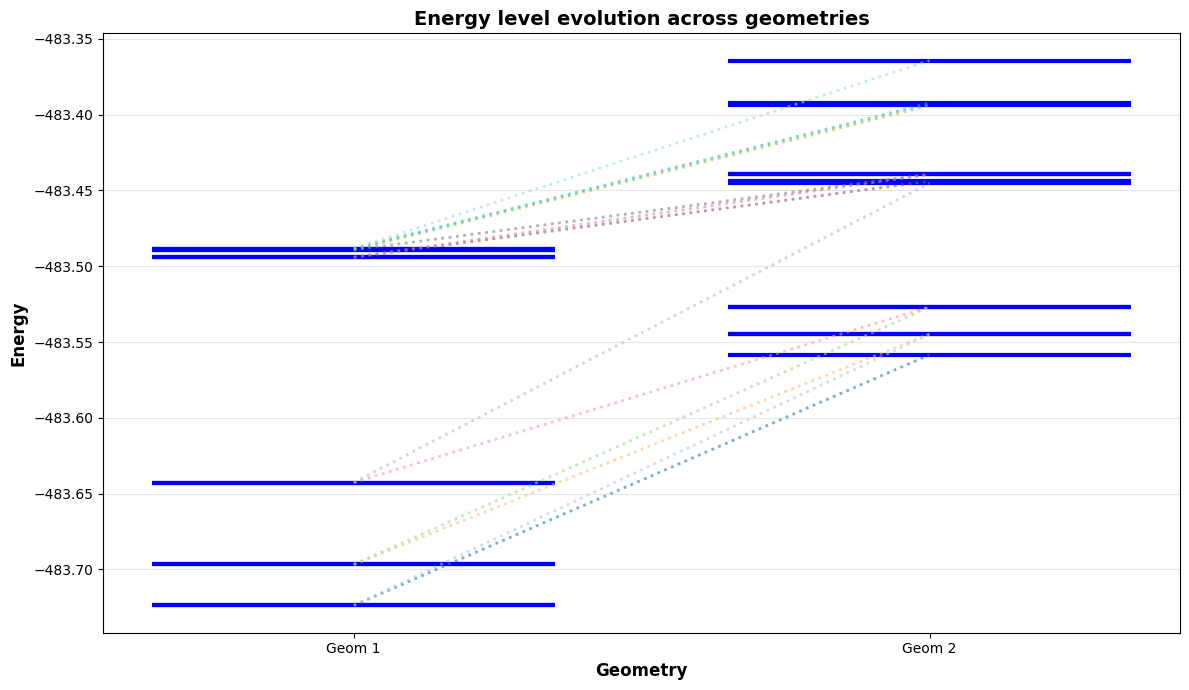

In [17]:
# Compute eigenvalues for all geometries
low_evals_list1 = []

for i1, noncontextual_qubit_op1 in enumerate(noncontextual_qubit_ops1):
    if i1 == 0:
        print(f"\n{'='*60}")
        print(f"Computing eigenvalues for Geometry {i1+1} (easy case)")
        print(f"{'='*60}")
    else:
        print(f"\n{'='*60}")
        print(f"Computing eigenvalues for Geometry {i1+1} (TS case)")
        print(f"{'='*60}")
    
    low_evals1 = get_lowest_eigenvalues_qubit(noncontextual_qubit_op1, k=12)
    low_evals_list1.append(low_evals1)
    
    print(f"Lowest eigenvalues for Geometry {i1+1}:")
    print(low_evals1)

# Plot all geometries together
plot_spectrum_all_geometries(
    low_evals_list1,
    title="Energy level evolution across geometries"
)

In [22]:
low_evals_list1[0][0]

-483.72381860474917

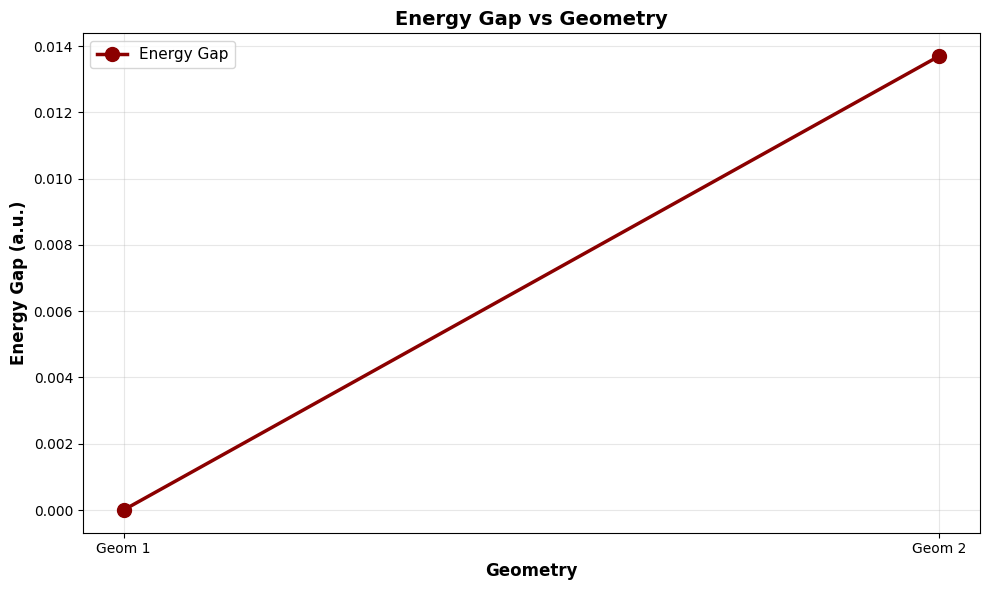


Energy gaps for each geometry:
Geometry 1: Gap = 0.000000 a.u.
Geometry 2: Gap = 0.013698 a.u.


In [20]:
plot_energy_gap(low_evals_list1, title="Energy Gap vs Geometry")